In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from xgboost import XGBRegressor

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

import warnings
warnings.filterwarnings("ignore")

In [2]:
file_path = r"D:\MSC THESIS AAVAS\AFTER MID DEFENSE\data without influencing point.xlsx"

df = pd.read_excel(file_path)

In [3]:
df.head()

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Left Shoulder Type,Right Shoulder Width,Right Shoulder Type
0,1,57.0,1.27,1500,5.5,0.9,Gravel,0.9,Gravel
1,2,33.0,2.92,46,5.5,0.9,Gravel,0.9,Gravel
2,3,43.0,7.97,1500,5.5,0.9,Gravel,0.9,Gravel
3,4,48.0,2.07,1500,5.5,0.9,Gravel,0.9,Gravel
4,5,36.0,1.21,16,5.5,0.9,Gravel,0.9,Gravel


In [4]:
df.describe()

,SN,V85 Speed,Gradient,Radius of Curve,Carriageway Width,Left Shoulder Width,Right Shoulder Width
count,164.00000,164.000000,164.000000,164.000000,164.000000,164.000000,164.000000
mean,82.50000,44.776220,4.140991,452.878049,6.287274,0.609573,0.620488
std,47.48684,9.443517,2.482151,629.633049,0.906803,0.408720,0.398334
min,1.00000,25.000000,0.070000,15.000000,4.700000,0.000000,0.000000
25%,41.75000,37.750000,1.887500,35.000000,5.500000,0.100000,0.357500
50%,82.50000,44.000000,4.092500,75.000000,7.000000,0.695000,0.745000
75%,123.25000,51.137500,6.111250,1500.000000,7.000000,1.000000,1.000000
max,164.00000,67.000000,10.000000,1500.000000,8.000000,1.130000,1.180000


In [5]:
df.shape

(164, 9)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 164 entries, 0 to 163
Data columns (total 9 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SN                    164 non-null    int64  
 1   V85 Speed             164 non-null    float64
 2   Gradient              164 non-null    float64
 3   Radius of Curve       164 non-null    int64  
 4   Carriageway Width     164 non-null    float64
 5   Left Shoulder Width   164 non-null    float64
 6   Left Shoulder Type    164 non-null    str    
 7   Right Shoulder Width  164 non-null    float64
 8   Right Shoulder Type   164 non-null    str    
dtypes: float64(5), int64(2), str(2)
memory usage: 11.7 KB


In [7]:
df.isnull().sum()

SN                      0
V85 Speed               0
Gradient                0
Radius of Curve         0
Carriageway Width       0
Left Shoulder Width     0
Left Shoulder Type      0
Right Shoulder Width    0
Right Shoulder Type     0
dtype: int64

In [8]:
df["Left Shoulder Type"] = df["Left Shoulder Type"].str.strip().str.lower().str.capitalize()
df["Right Shoulder Type"] = df["Right Shoulder Type"].str.strip().str.lower().str.capitalize()

In [9]:
df_encoded = pd.get_dummies(
    df,
    columns=["Left Shoulder Type", "Right Shoulder Type"],
    drop_first=True,
    dtype=int
)

In [10]:
X_vif = df_encoded[
    [
        "Gradient",
        "Radius of Curve",
        "Carriageway Width",
        "Left Shoulder Width",
        "Right Shoulder Width",
        "Left Shoulder Type_Gravel",
        "Left Shoulder Type_Paved",
        "Right Shoulder Type_Gravel",
        "Right Shoulder Type_Paved"
    ]
]

X_vif = X_vif.astype(float)
X_vif_const = sm.add_constant(X_vif)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif_const.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_vif_const.values, i)
    for i in range(X_vif_const.shape[1])
]

vif_data

,Feature,VIF
0,const,98.368064
1,Gradient,1.109357
2,Radius of Curve,1.085565
3,Carriageway Width,1.226451
4,Left Shoulder Width,6.117080
5,Right Shoulder Width,5.073976
6,Left Shoulder Type_Gravel,7.555686
7,Left Shoulder Type_Paved,7.285221
8,Right Shoulder Type_Gravel,6.005801
9,Right Shoulder Type_Paved,7.252284


In [11]:
# Create average shoulder width
df_encoded["Average Shoulder Width"] = (
    df_encoded["Left Shoulder Width"] +
    df_encoded["Right Shoulder Width"]
) / 2

# Check the new variable
df_encoded[
    ["Left Shoulder Width", "Right Shoulder Width", "Average Shoulder Width"]
].head()

,Left Shoulder Width,Right Shoulder Width,Average Shoulder Width
0,0.9,0.9,0.9
1,0.9,0.9,0.9
2,0.9,0.9,0.9
3,0.9,0.9,0.9
4,0.9,0.9,0.9


In [12]:
X_vif_avg = df_encoded[
    [
        "Gradient",
        "Radius of Curve",
        "Carriageway Width",
        "Average Shoulder Width"
    ]
]

# Convert to float
X_vif_avg = X_vif_avg.astype(float)

# Add constant
X_vif_avg_const = sm.add_constant(X_vif_avg)

# Calculate VIF
vif_data_avg = pd.DataFrame()

vif_data_avg["Feature"] = X_vif_avg_const.columns

vif_data_avg["VIF"] = [
    variance_inflation_factor(X_vif_avg_const.values, i)
    for i in range(X_vif_avg_const.shape[1])
]

vif_data_avg

,Feature,VIF
0,const,64.597011
1,Gradient,1.060287
2,Radius of Curve,1.045893
3,Carriageway Width,1.028388
4,Average Shoulder Width,1.020243


In [13]:
X = df_encoded[
    [
        "Gradient",
        "Radius of Curve",
        "Carriageway Width",
        "Average Shoulder Width"
    ]
]

y = df_encoded["V85 Speed"]

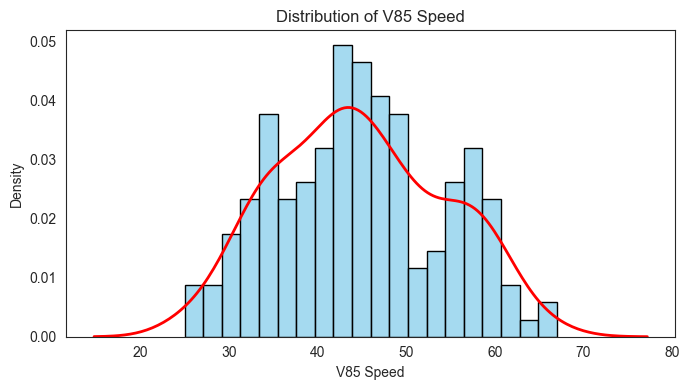

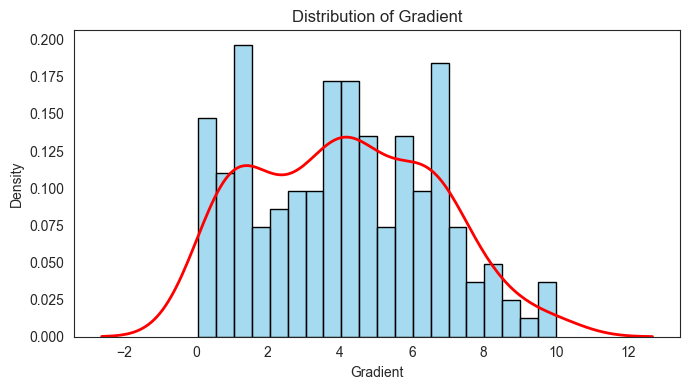

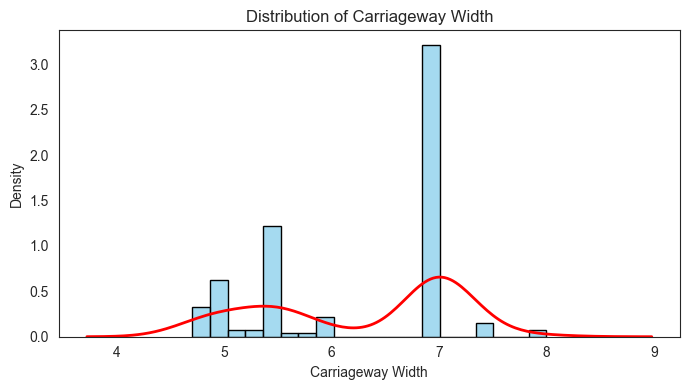

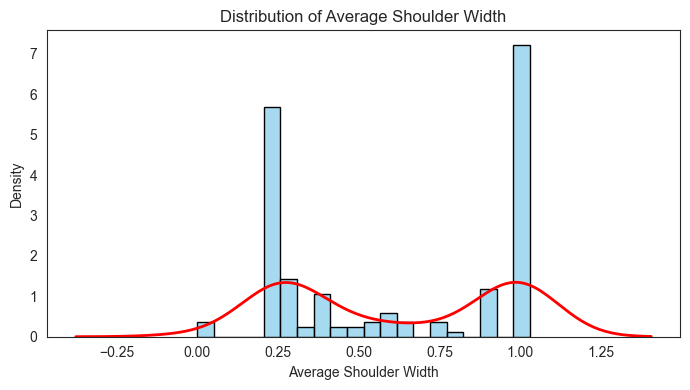

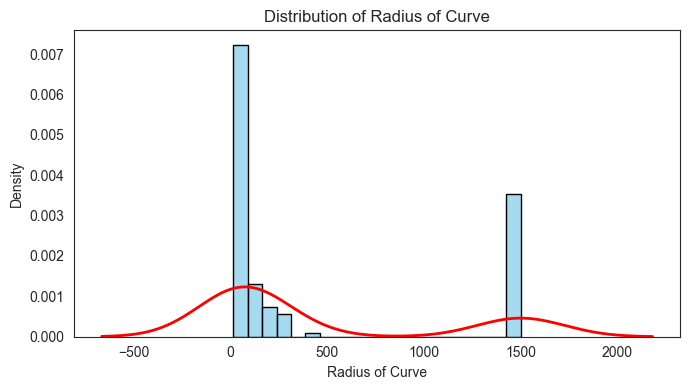

In [14]:
num_cols = [
    "V85 Speed",
    "Gradient",
    "Carriageway Width",
    "Average Shoulder Width",
    "Radius of Curve"
]

sns.set_style("white")

for col in num_cols:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        df_encoded[col],
        bins=20,
        stat="density",
        color="skyblue",
        edgecolor="black"
    )

    sns.kdeplot(
        df_encoded[col],
        color="red",
        linewidth=2
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")

    plt.tight_layout()
    plt.show()

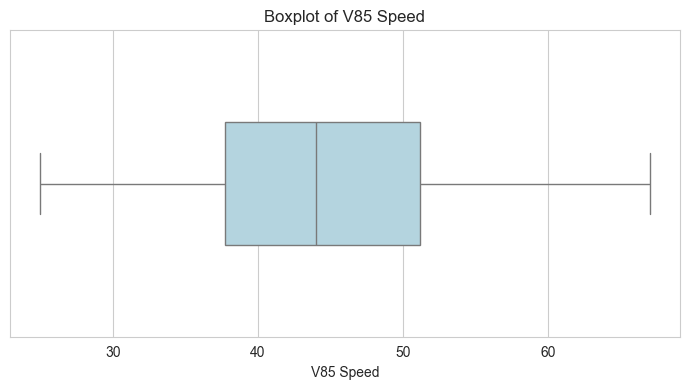

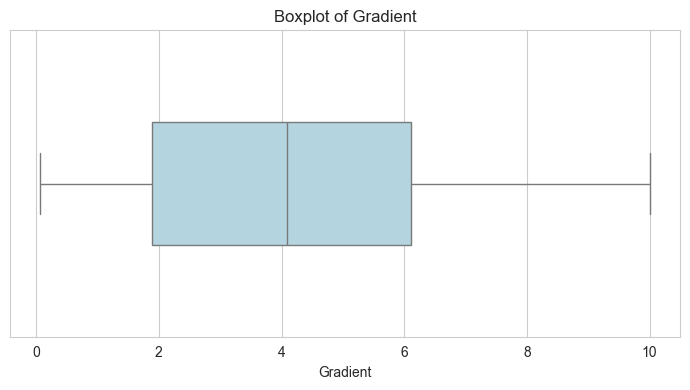

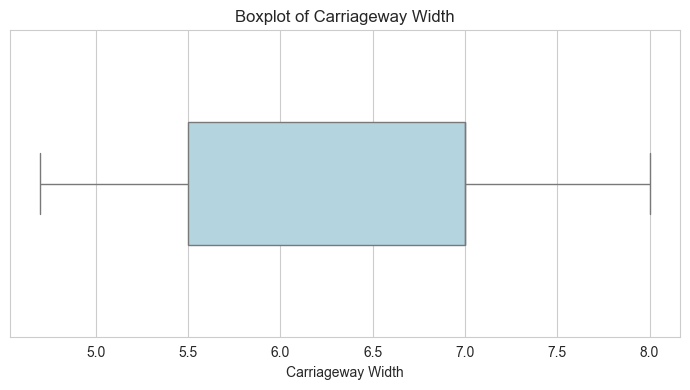

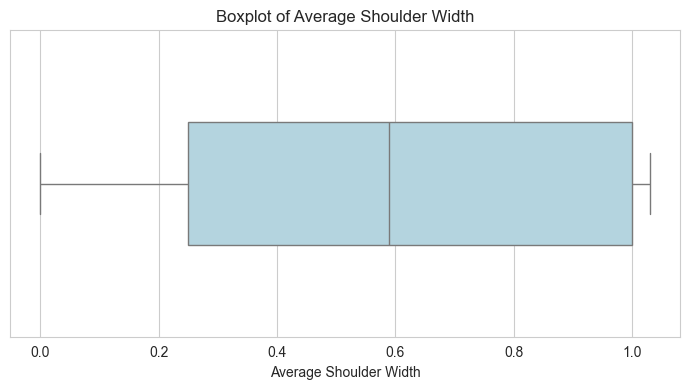

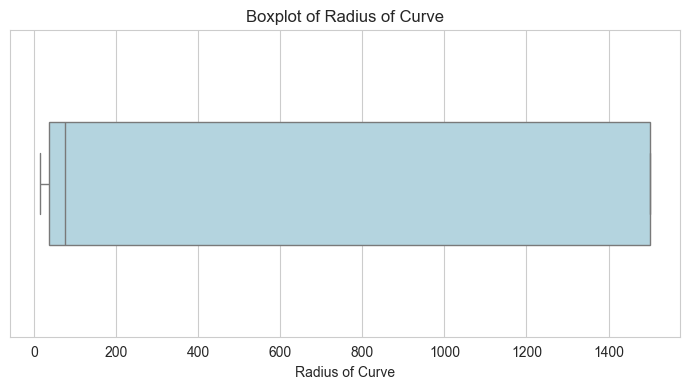

In [15]:
sns.set_style("whitegrid")

for col in num_cols:
    plt.figure(figsize=(7, 4))

    sns.boxplot(
        x=df_encoded[col],
        color="lightblue",
        width=0.4
    )

    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

In [16]:
skew_table = pd.DataFrame({
    "Variable": num_cols,
    "Skewness": df_encoded[num_cols].skew().values
})

skew_table

,Variable,Skewness
0,V85 Speed,0.139588
1,Gradient,0.190103
2,Carriageway Width,-0.396348
3,Average Shoulder Width,0.009769
4,Radius of Curve,1.055990


In [17]:
corr_matrix = df_encoded[num_cols].corr()
corr_matrix

,V85 Speed,Gradient,Carriageway Width,Average Shoulder Width,Radius of Curve
V85 Speed,1.000000,-0.117333,0.088934,-0.202152,0.615085
Gradient,-0.117333,1.000000,-0.149820,-0.048230,-0.167797
Carriageway Width,0.088934,-0.149820,1.000000,-0.047199,-0.014319
Average Shoulder Width,-0.202152,-0.048230,-0.047199,1.000000,-0.108262
Radius of Curve,0.615085,-0.167797,-0.014319,-0.108262,1.000000


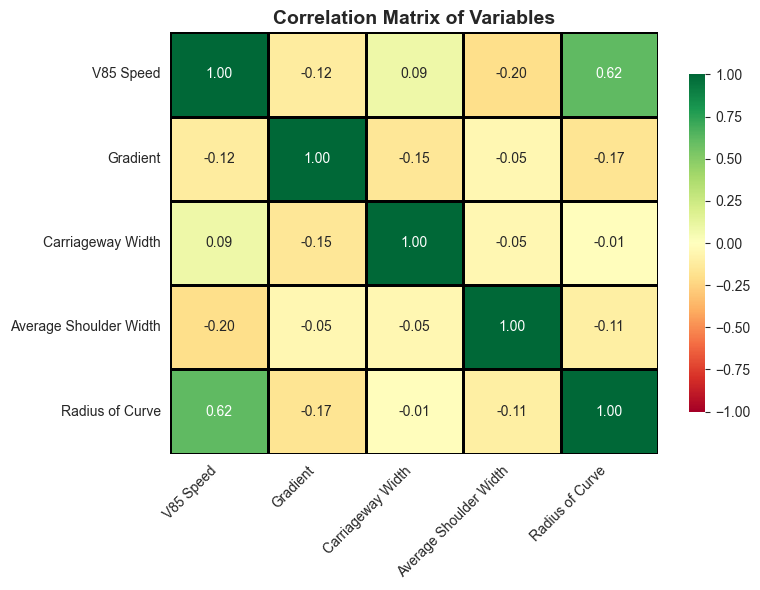

In [18]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="RdYlGn",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f",
    linewidths=0.8,
    linecolor="black",
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Variables", fontsize=14, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

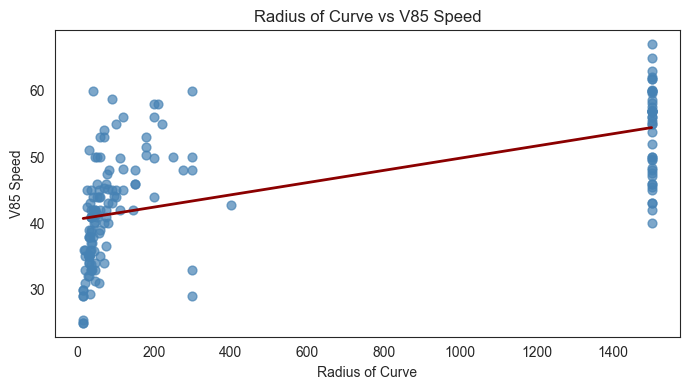

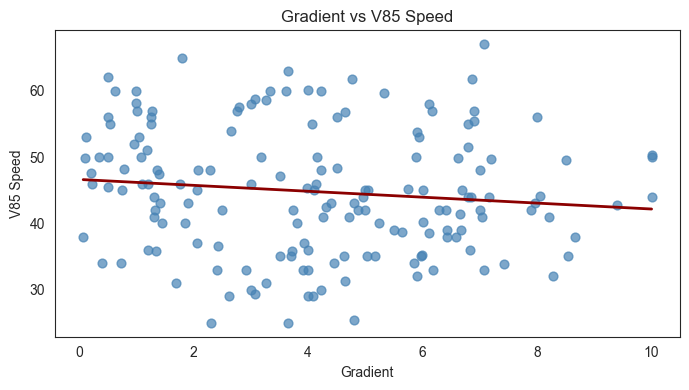

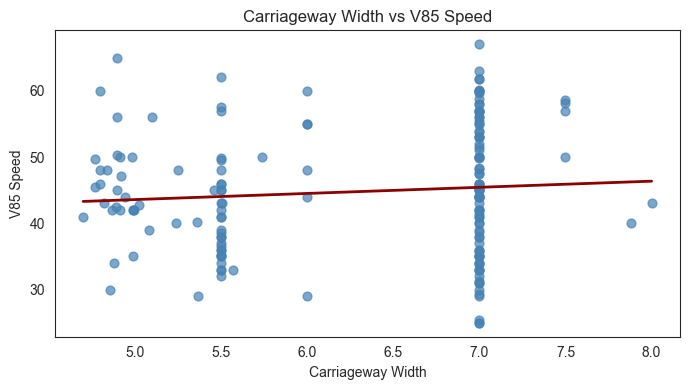

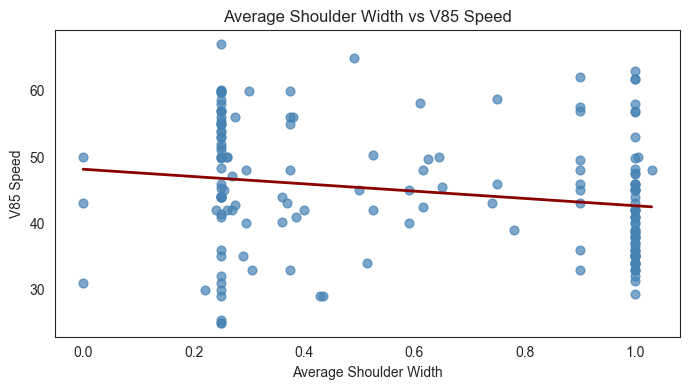

In [19]:
predictor_cols = [
    "Radius of Curve",
    "Gradient",
    "Carriageway Width",
    "Average Shoulder Width"
]

sns.set_style("white")

for col in predictor_cols:
    plt.figure(figsize=(7, 4))

    sns.regplot(
        x=df_encoded[col],
        y=df_encoded["V85 Speed"],
        scatter_kws={"s": 40, "color": "steelblue", "alpha": 0.7},
        line_kws={"color": "darkred", "linewidth": 2},
        ci=None
    )

    plt.title(f"{col} vs V85 Speed")
    plt.xlabel(col)
    plt.ylabel("V85 Speed")

    plt.tight_layout()
    plt.show()

In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (131, 4)
X_test shape : (33, 4)
y_train shape: (131,)
y_test shape : (33,)


In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [22]:
from sklearn.linear_model import LinearRegression

mlr = LinearRegression()
mlr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [23]:
y_train_pred_mlr = mlr.predict(X_train_scaled)
y_test_pred_mlr = mlr.predict(X_test_scaled)

In [24]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np
import pandas as pd

mlr_train_r2 = r2_score(y_train, y_train_pred_mlr)
mlr_test_r2 = r2_score(y_test, y_test_pred_mlr)

mlr_train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred_mlr))
mlr_test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_mlr))

mlr_train_mae = mean_absolute_error(y_train, y_train_pred_mlr)
mlr_test_mae = mean_absolute_error(y_test, y_test_pred_mlr)

mlr_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Value": [mlr_test_r2, mlr_test_rmse, mlr_test_mae]
})

mlr_results

,Metric,Value
0,R2,0.283381
1,RMSE,6.088298
2,MAE,4.802669


In [25]:
mlr_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Training": [
        mlr_train_r2,
        mlr_train_rmse,
        mlr_train_mae
    ],
    "Testing": [
        mlr_test_r2,
        mlr_test_rmse,
        mlr_test_mae
    ]
})

mlr_results

,Metric,Training,Testing
0,R2,0.412615,0.283381
1,RMSE,7.535512,6.088298
2,MAE,6.038950,4.802669


In [26]:
comparison = pd.DataFrame({
    "Dataset": ["Training", "Testing"],
    "N": [len(y_train), len(y_test)],
    "Mean V85": [y_train.mean(), y_test.mean()],
    "Std V85": [y_train.std(), y_test.std()],
    "Min V85": [y_train.min(), y_test.min()],
    "Max V85": [y_train.max(), y_test.max()]
})

comparison

,Dataset,N,Mean V85,Std V85,Min V85,Max V85
0,Training,131,45.280153,9.869954,25.00,67.0
1,Testing,33,42.775758,7.303543,25.35,58.2


In [27]:

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    random_state=42
)

rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [28]:
y_train_pred_rf = rf.predict(X_train)
y_test_pred_rf = rf.predict(X_test)

In [29]:
rf_train_r2 = r2_score(y_train, y_train_pred_rf)
rf_test_r2 = r2_score(y_test, y_test_pred_rf)

rf_train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred_rf)
)

rf_test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_rf)
)

rf_train_mae = mean_absolute_error(
    y_train, y_train_pred_rf
)

rf_test_mae = mean_absolute_error(
    y_test, y_test_pred_rf
)

In [30]:
rf_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Training": [
        rf_train_r2,
        rf_train_rmse,
        rf_train_mae
    ],
    "Testing": [
        rf_test_r2,
        rf_test_rmse,
        rf_test_mae
    ]
})

rf_results

,Metric,Training,Testing
0,R2,0.931010,0.598076
1,RMSE,2.582530,4.559566
2,MAE,2.004099,3.593485


In [31]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_importance

,Feature,Importance
1,Radius of Curve,0.654724
0,Gradient,0.204178
3,Average Shoulder Width,0.071014
2,Carriageway Width,0.070084


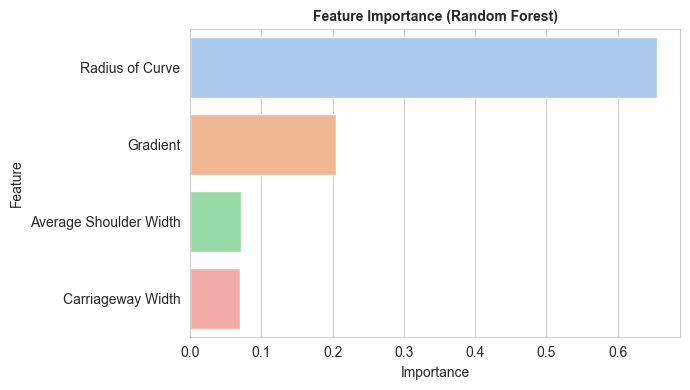

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(7, 4))

sns.barplot(
    x="Importance",
    y="Feature",
    data=rf_importance,  # make sure this matches your dataframe
    palette="pastel"
)

plt.title("Feature Importance (Random Forest)", fontsize=10, fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [33]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

# Use UNSCALED training data for Random Forest
grid_rf.fit(X_train, y_train)

print("Tuning completed")
print("Best Parameters:", grid_rf.best_params_)
print("Best CV Score:", round(grid_rf.best_score_, 3))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Tuning completed
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV Score: 0.51


In [35]:
best_rf = grid_rf.best_estimator_
best_rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [36]:
# Predictions using Tuned Random Forest Model

y_train_pred_rf_tuned = best_rf.predict(X_train)
y_test_pred_rf_tuned = best_rf.predict(X_test)

In [37]:
# Model Evaluation Metrics

rf_tuned_train_r2 = r2_score(y_train, y_train_pred_rf_tuned)
rf_tuned_test_r2 = r2_score(y_test, y_test_pred_rf_tuned)

rf_tuned_train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred_rf_tuned)
)

rf_tuned_test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_rf_tuned)
)

rf_tuned_train_mae = mean_absolute_error(
    y_train, y_train_pred_rf_tuned
)

rf_tuned_test_mae = mean_absolute_error(
    y_test, y_test_pred_rf_tuned
)

In [38]:
rf_tuned_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Training": [
        rf_tuned_train_r2,
        rf_tuned_train_rmse,
        rf_tuned_train_mae
    ],
    "Testing": [
        rf_tuned_test_r2,
        rf_tuned_test_rmse,
        rf_tuned_test_mae
    ]
})

rf_tuned_results

,Metric,Training,Testing
0,R2,0.860434,0.588949
1,RMSE,3.673165,4.611046
2,MAE,2.858991,3.516933


In [39]:
from sklearn.model_selection import KFold, cross_validate, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
import numpy as np

outer_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "R2": "r2",
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error"
}

In [40]:
base_rf_cv = cross_validate(
    RandomForestRegressor(random_state=42),
    X_train,
    y_train,
    cv=outer_cv,
    scoring=scoring,
    n_jobs=-1
)

In [41]:
param_grid_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [42]:
inner_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

rf_grid_nested = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid_rf,
    cv=inner_cv,
    scoring="r2",
    n_jobs=-1
)

tuned_rf_cv = cross_validate(
    rf_grid_nested,
    X_train,
    y_train,
    cv=outer_cv,
    scoring=scoring,
    n_jobs=1
)

In [43]:
rf_cv_comparison = pd.DataFrame({
    "Model": ["Base RF", "Tuned RF"],

    "Mean CV R2": [
        base_rf_cv["test_R2"].mean(),
        tuned_rf_cv["test_R2"].mean()
    ],

    "SD R2": [
        base_rf_cv["test_R2"].std(),
        tuned_rf_cv["test_R2"].std()
    ],

    "Mean CV RMSE": [
        -base_rf_cv["test_RMSE"].mean(),
        -tuned_rf_cv["test_RMSE"].mean()
    ],

    "SD RMSE": [
        base_rf_cv["test_RMSE"].std(),
        tuned_rf_cv["test_RMSE"].std()
    ],

    "Mean CV MAE": [
        -base_rf_cv["test_MAE"].mean(),
        -tuned_rf_cv["test_MAE"].mean()
    ]
})

rf_cv_comparison.round(3)

,Model,Mean CV R2,SD R2,Mean CV RMSE,SD RMSE,Mean CV MAE
0,Base RF,0.488,0.120,6.863,1.102,5.387
1,Tuned RF,0.507,0.083,6.805,1.209,5.428


In [44]:
rf_tuned_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

rf_tuned_importance

,Feature,Importance
1,Radius of Curve,0.620322
0,Gradient,0.213703
3,Average Shoulder Width,0.091683
2,Carriageway Width,0.074291


In [45]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    random_state=42,
    objective="reg:squarederror"
)

xgb.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [46]:
y_train_pred_xgb = xgb.predict(X_train)
y_test_pred_xgb = xgb.predict(X_test)

In [47]:
xgb_train_r2 = r2_score(y_train, y_train_pred_xgb)
xgb_test_r2 = r2_score(y_test, y_test_pred_xgb)

xgb_train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred_xgb)
)

xgb_test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_xgb)
)

xgb_train_mae = mean_absolute_error(
    y_train, y_train_pred_xgb
)

xgb_test_mae = mean_absolute_error(
    y_test, y_test_pred_xgb
)

In [48]:
xgb_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Training": [
        xgb_train_r2,
        xgb_train_rmse,
        xgb_train_mae
    ],
    "Testing": [
        xgb_test_r2,
        xgb_test_rmse,
        xgb_test_mae
    ]
})

xgb_results

,Metric,Training,Testing
0,R2,0.999997,0.162306
1,RMSE,0.016590,6.582551
2,MAE,0.011904,5.231224


In [49]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [50]:
grid_xgb = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_grid=param_grid_xgb,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

# Use UNSCALED training data
grid_xgb.fit(X_train, y_train)

print("Best Parameters:", grid_xgb.best_params_)
print("Best CV Score:", round(grid_xgb.best_score_, 3))

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best Parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.7}
Best CV Score: 0.484


In [51]:
best_xgb = grid_xgb.best_estimator_

In [52]:
# Predictions Using Tuned XGBoost Model

y_train_pred_xgb_tuned = best_xgb.predict(X_train)
y_test_pred_xgb_tuned = best_xgb.predict(X_test)

In [53]:
# Model Evaluation Metrics

xgb_tuned_train_r2 = r2_score(y_train, y_train_pred_xgb_tuned)
xgb_tuned_test_r2 = r2_score(y_test, y_test_pred_xgb_tuned)

xgb_tuned_train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred_xgb_tuned)
)

xgb_tuned_test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_xgb_tuned)
)

xgb_tuned_train_mae = mean_absolute_error(
    y_train, y_train_pred_xgb_tuned
)

xgb_tuned_test_mae = mean_absolute_error(
    y_test, y_test_pred_xgb_tuned
)

In [54]:
xgb_tuned_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Training": [
        xgb_tuned_train_r2,
        xgb_tuned_train_rmse,
        xgb_tuned_train_mae
    ],
    "Testing": [
        xgb_tuned_test_r2,
        xgb_tuned_test_rmse,
        xgb_tuned_test_mae
    ]
})

xgb_tuned_results

,Metric,Training,Testing
0,R2,0.716477,0.609941
1,RMSE,5.235343,4.491760
2,MAE,4.150791,3.412983


In [55]:
from sklearn.svm import SVR

svr = SVR(
    kernel="rbf",
    C=100,
    epsilon=0.1,
    gamma="scale"
)

svr.fit(X_train_scaled, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [56]:
y_train_pred_svr = svr.predict(X_train_scaled)
y_test_pred_svr = svr.predict(X_test_scaled)

In [57]:
svr_train_r2 = r2_score(y_train, y_train_pred_svr)
svr_test_r2 = r2_score(y_test, y_test_pred_svr)

svr_train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred_svr)
)

svr_test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_svr)
)

svr_train_mae = mean_absolute_error(
    y_train, y_train_pred_svr
)

svr_test_mae = mean_absolute_error(
    y_test, y_test_pred_svr
)

svr_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Training": [
        svr_train_r2,
        svr_train_rmse,
        svr_train_mae
    ],
    "Testing": [
        svr_test_r2,
        svr_test_rmse,
        svr_test_mae
    ]
})

svr_results

,Metric,Training,Testing
0,R2,0.615146,0.183285
1,RMSE,6.099571,6.499602
2,MAE,4.014304,4.917305


In [58]:
param_grid_svr = {
    "C": [1, 10, 100, 1000],
    "epsilon": [0.01, 0.1, 0.5, 1],
    "gamma": ["scale", 0.01, 0.1, 1],
    "kernel": ["rbf"]
}

In [59]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

grid_svr = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_svr,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_svr.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_svr.best_params_)
print("Best CV Score:", round(grid_svr.best_score_, 3))

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters: {'C': 100, 'epsilon': 0.5, 'gamma': 0.01, 'kernel': 'rbf'}
Best CV Score: 0.326


In [60]:
best_svr = grid_svr.best_estimator_

In [61]:
y_train_pred_svr_tuned = best_svr.predict(X_train_scaled)
y_test_pred_svr_tuned = best_svr.predict(X_test_scaled)

In [62]:
svr_tuned_train_r2 = r2_score(
    y_train,
    y_train_pred_svr_tuned
)

svr_tuned_test_r2 = r2_score(
    y_test,
    y_test_pred_svr_tuned
)

svr_tuned_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_svr_tuned
    )
)

svr_tuned_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_svr_tuned
    )
)

svr_tuned_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_svr_tuned
)

svr_tuned_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_svr_tuned
)

In [63]:
svr_tuned_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Training": [
        svr_tuned_train_r2,
        svr_tuned_train_rmse,
        svr_tuned_train_mae
    ],
    "Testing": [
        svr_tuned_test_r2,
        svr_tuned_test_rmse,
        svr_tuned_test_mae
    ]
})

svr_tuned_results

,Metric,Training,Testing
0,R2,0.424760,0.265525
1,RMSE,7.457196,6.163682
2,MAE,5.826102,4.686894


In [64]:
from sklearn.neural_network import MLPRegressor

ann = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation="relu",
    solver="adam",
    alpha=0.001,
    learning_rate_init=0.01,
    max_iter=2000,
    random_state=42
)

ann.fit(X_train_scaled, y_train)

,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",2000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [65]:
y_train_pred_ann = ann.predict(X_train_scaled)
y_test_pred_ann = ann.predict(X_test_scaled)

In [66]:
ann_train_r2 = r2_score(y_train, y_train_pred_ann)
ann_test_r2 = r2_score(y_test, y_test_pred_ann)

ann_train_rmse = np.sqrt(
    mean_squared_error(y_train, y_train_pred_ann)
)

ann_test_rmse = np.sqrt(
    mean_squared_error(y_test, y_test_pred_ann)
)

ann_train_mae = mean_absolute_error(
    y_train, y_train_pred_ann
)

ann_test_mae = mean_absolute_error(
    y_test, y_test_pred_ann
)

ann_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Training": [
        ann_train_r2,
        ann_train_rmse,
        ann_train_mae
    ],
    "Testing": [
        ann_test_r2,
        ann_test_rmse,
        ann_test_mae
    ]
})

ann_results

,Metric,Training,Testing
0,R2,0.244926,-0.245136
1,RMSE,8.543696,8.025277
2,MAE,6.464901,6.745649


In [67]:
param_grid_ann = {
    "hidden_layer_sizes": [(16,), (32,), (64,), (32, 16), (64, 32), (128, 64)],
    "activation": ["relu", "tanh"],
    "alpha": [0.0001, 0.001, 0.01],
    "learning_rate_init": [0.001, 0.01]
}

In [68]:
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPRegressor

grid_ann = GridSearchCV(
    estimator=MLPRegressor(
        max_iter=3000,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.15,
        n_iter_no_change=30
    ),
    param_grid=param_grid_ann,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

grid_ann.fit(X_train_scaled, y_train)

print("Best Parameters:", grid_ann.best_params_)
print("Best CV Score:", round(grid_ann.best_score_, 3))

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'activation': 'tanh', 'alpha': 0.0001, 'hidden_layer_sizes': (16,), 'learning_rate_init': 0.01}
Best CV Score: 0.401


In [69]:
best_ann = grid_ann.best_estimator_

In [70]:
y_train_pred_ann_tuned = best_ann.predict(X_train_scaled)
y_test_pred_ann_tuned = best_ann.predict(X_test_scaled)

In [71]:
ann_tuned_train_r2 = r2_score(
    y_train,
    y_train_pred_ann_tuned
)

ann_tuned_test_r2 = r2_score(
    y_test,
    y_test_pred_ann_tuned
)

ann_tuned_train_rmse = np.sqrt(
    mean_squared_error(
        y_train,
        y_train_pred_ann_tuned
    )
)

ann_tuned_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_ann_tuned
    )
)

ann_tuned_train_mae = mean_absolute_error(
    y_train,
    y_train_pred_ann_tuned
)

ann_tuned_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_ann_tuned
)

In [72]:
ann_tuned_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Training": [
        ann_tuned_train_r2,
        ann_tuned_train_rmse,
        ann_tuned_train_mae
    ],
    "Testing": [
        ann_tuned_test_r2,
        ann_tuned_test_rmse,
        ann_tuned_test_mae
    ]
})

ann_tuned_results

,Metric,Training,Testing
0,R2,0.435834,0.409315
1,RMSE,7.385072,5.527509
2,MAE,6.002481,4.493811


In [73]:
model_comparison = pd.DataFrame({
    "Model": [
        "MLR",
        "Base Random Forest",
        "Tuned Random Forest",
        "Base XGBoost",
        "Tuned XGBoost",
        "Base SVR",
        "Tuned SVR",
        "Base ANN",
        "Tuned ANN"
    ],

    "Train R2": [
        mlr_train_r2,
        rf_train_r2,
        rf_tuned_train_r2,
        xgb_train_r2,
        xgb_tuned_train_r2,
        svr_train_r2,
        svr_tuned_train_r2,
        ann_train_r2,
        ann_tuned_train_r2
    ],

    "Test R2": [
        mlr_test_r2,
        rf_test_r2,
        rf_tuned_test_r2,
        xgb_test_r2,
        xgb_tuned_test_r2,
        svr_test_r2,
        svr_tuned_test_r2,
        ann_test_r2,
        ann_tuned_test_r2
    ],

    "Train RMSE": [
        mlr_train_rmse,
        rf_train_rmse,
        rf_tuned_train_rmse,
        xgb_train_rmse,
        xgb_tuned_train_rmse,
        svr_train_rmse,
        svr_tuned_train_rmse,
        ann_train_rmse,
        ann_tuned_train_rmse
    ],

    "Test RMSE": [
        mlr_test_rmse,
        rf_test_rmse,
        rf_tuned_test_rmse,
        xgb_test_rmse,
        xgb_tuned_test_rmse,
        svr_test_rmse,
        svr_tuned_test_rmse,
        ann_test_rmse,
        ann_tuned_test_rmse
    ],

    "Train MAE": [
        mlr_train_mae,
        rf_train_mae,
        rf_tuned_train_mae,
        xgb_train_mae,
        xgb_tuned_train_mae,
        svr_train_mae,
        svr_tuned_train_mae,
        ann_train_mae,
        ann_tuned_train_mae
    ],

    "Test MAE": [
        mlr_test_mae,
        rf_test_mae,
        rf_tuned_test_mae,
        xgb_test_mae,
        xgb_tuned_test_mae,
        svr_test_mae,
        svr_tuned_test_mae,
        ann_test_mae,
        ann_tuned_test_mae
    ]
})

model_comparison = model_comparison.round(3)

model_comparison

,Model,Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE
0,MLR,0.413,0.283,7.536,6.088,6.039,4.803
1,Base Random Forest,0.931,0.598,2.583,4.560,2.004,3.593
2,Tuned Random Forest,0.860,0.589,3.673,4.611,2.859,3.517
3,Base XGBoost,1.000,0.162,0.017,6.583,0.012,5.231
4,Tuned XGBoost,0.716,0.610,5.235,4.492,4.151,3.413
5,Base SVR,0.615,0.183,6.100,6.500,4.014,4.917
6,Tuned SVR,0.425,0.266,7.457,6.164,5.826,4.687
7,Base ANN,0.245,-0.245,8.544,8.025,6.465,6.746
8,Tuned ANN,0.436,0.409,7.385,5.528,6.002,4.494


In [74]:
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "R2": "r2",
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error"
}

In [75]:
# MLR
mlr_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])


# Tuned Random Forest
rf_cv_model = best_rf


# Tuned XGBoost
xgb_cv_model = best_xgb


# Tuned SVR
svr_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVR(**best_svr.get_params()))
])


# Tuned ANN
ann_cv_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", MLPRegressor(**best_ann.get_params()))
])

In [76]:
models_cv = {
    "MLR": mlr_cv_model,
    "Tuned RF": rf_cv_model,
    "Tuned XGBoost": xgb_cv_model,
    "Tuned SVR": svr_cv_model,
    "Tuned ANN": ann_cv_model
}

cv_results_list = []

for name, model in models_cv.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    cv_results_list.append({
        "Model": name,

        "Mean CV R2": scores["test_R2"].mean(),
        "SD R2": scores["test_R2"].std(),

        "Mean CV RMSE": -scores["test_RMSE"].mean(),
        "SD RMSE": scores["test_RMSE"].std(),

        "Mean CV MAE": -scores["test_MAE"].mean(),
        "SD MAE": scores["test_MAE"].std()
    })

cv_comparison = pd.DataFrame(cv_results_list)

cv_comparison.round(3)

,Model,Mean CV R2,SD R2,Mean CV RMSE,SD RMSE,Mean CV MAE,SD MAE
0,MLR,0.359,0.085,7.706,1.006,6.231,0.988
1,Tuned RF,0.520,0.081,6.691,1.086,5.325,0.872
2,Tuned XGBoost,0.504,0.065,6.825,1.128,5.467,0.957
3,Tuned SVR,0.347,0.065,7.811,1.162,6.335,1.025
4,Tuned ANN,0.428,0.073,7.343,1.305,6.020,1.339


In [77]:
from sklearn.model_selection import KFold, GridSearchCV, cross_validate
from xgboost import XGBRegressor

# Outer CV: evaluates the tuned model
outer_cv_xgb = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Inner CV: selects hyperparameters
inner_cv_xgb = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "R2": "r2",
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error"
}

In [78]:
param_grid_xgb = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0]
}

In [79]:
xgb_grid_nested = GridSearchCV(
    estimator=XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ),
    param_grid=param_grid_xgb,
    cv=inner_cv_xgb,
    scoring="r2",
    n_jobs=-1
)

In [80]:
nested_xgb_cv = cross_validate(
    xgb_grid_nested,
    X_train,
    y_train,
    cv=outer_cv_xgb,
    scoring=scoring,
    n_jobs=1
)

In [81]:
nested_xgb_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],

    "Mean": [
        nested_xgb_cv["test_R2"].mean(),
        -nested_xgb_cv["test_RMSE"].mean(),
        -nested_xgb_cv["test_MAE"].mean()
    ],

    "SD": [
        nested_xgb_cv["test_R2"].std(),
        nested_xgb_cv["test_RMSE"].std(),
        nested_xgb_cv["test_MAE"].std()
    ]
})

nested_xgb_results.round(3)

,Metric,Mean,SD
0,R2,0.499,0.068
1,RMSE,6.861,1.152
2,MAE,5.482,0.940


In [82]:
final_nested_comparison = pd.DataFrame({
    "Model": [
        "Tuned Random Forest",
        "Tuned XGBoost"
    ],

    "Mean Nested CV R2": [
        tuned_rf_cv["test_R2"].mean(),
        nested_xgb_cv["test_R2"].mean()
    ],

    "SD R2": [
        tuned_rf_cv["test_R2"].std(),
        nested_xgb_cv["test_R2"].std()
    ],

    "Mean Nested CV RMSE": [
        -tuned_rf_cv["test_RMSE"].mean(),
        -nested_xgb_cv["test_RMSE"].mean()
    ],

    "SD RMSE": [
        tuned_rf_cv["test_RMSE"].std(),
        nested_xgb_cv["test_RMSE"].std()
    ],

    "Mean Nested CV MAE": [
        -tuned_rf_cv["test_MAE"].mean(),
        -nested_xgb_cv["test_MAE"].mean()
    ],

    "SD MAE": [
        tuned_rf_cv["test_MAE"].std(),
        nested_xgb_cv["test_MAE"].std()
    ]
})

final_nested_comparison.round(3)

,Model,Mean Nested CV R2,SD R2,Mean Nested CV RMSE,SD RMSE,Mean Nested CV MAE,SD MAE
0,Tuned Random Forest,0.507,0.083,6.805,1.209,5.428,0.963
1,Tuned XGBoost,0.499,0.068,6.861,1.152,5.482,0.940


In [83]:
import numpy as np
import pandas as pd

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Convert to NumPy arrays
y_test_np = np.asarray(y_test)

rf_pred_np = np.asarray(y_test_pred_rf_tuned)
xgb_pred_np = np.asarray(y_test_pred_xgb_tuned)

# Number of bootstrap samples
n_bootstrap = 1000

# Reproducibility
rng = np.random.default_rng(42)

rf_boot_r2 = []
rf_boot_rmse = []
rf_boot_mae = []

xgb_boot_r2 = []
xgb_boot_rmse = []
xgb_boot_mae = []

n_test = len(y_test_np)

for i in range(n_bootstrap):

    # Sample test observations with replacement
    idx = rng.choice(
        np.arange(n_test),
        size=n_test,
        replace=True
    )

    y_boot = y_test_np[idx]

    rf_boot_pred = rf_pred_np[idx]
    xgb_boot_pred = xgb_pred_np[idx]

    # Avoid rare bootstrap samples with no variance in y
    if np.var(y_boot) == 0:
        continue

    # Random Forest
    rf_boot_r2.append(
        r2_score(y_boot, rf_boot_pred)
    )

    rf_boot_rmse.append(
        np.sqrt(
            mean_squared_error(y_boot, rf_boot_pred)
        )
    )

    rf_boot_mae.append(
        mean_absolute_error(y_boot, rf_boot_pred)
    )

    # XGBoost
    xgb_boot_r2.append(
        r2_score(y_boot, xgb_boot_pred)
    )

    xgb_boot_rmse.append(
        np.sqrt(
            mean_squared_error(y_boot, xgb_boot_pred)
        )
    )

    xgb_boot_mae.append(
        mean_absolute_error(y_boot, xgb_boot_pred)
    )

In [84]:
def bootstrap_ci(values):
    lower = np.percentile(values, 2.5)
    upper = np.percentile(values, 97.5)
    mean = np.mean(values)

    return mean, lower, upper

In [85]:
rf_r2_mean, rf_r2_low, rf_r2_high = bootstrap_ci(rf_boot_r2)
rf_rmse_mean, rf_rmse_low, rf_rmse_high = bootstrap_ci(rf_boot_rmse)
rf_mae_mean, rf_mae_low, rf_mae_high = bootstrap_ci(rf_boot_mae)

xgb_r2_mean, xgb_r2_low, xgb_r2_high = bootstrap_ci(xgb_boot_r2)
xgb_rmse_mean, xgb_rmse_low, xgb_rmse_high = bootstrap_ci(xgb_boot_rmse)
xgb_mae_mean, xgb_mae_low, xgb_mae_high = bootstrap_ci(xgb_boot_mae)

In [86]:
bootstrap_results = pd.DataFrame({
    "Model": [
        "Tuned Random Forest",
        "Tuned Random Forest",
        "Tuned Random Forest",
        "Tuned XGBoost",
        "Tuned XGBoost",
        "Tuned XGBoost"
    ],

    "Metric": [
        "R2",
        "RMSE",
        "MAE",
        "R2",
        "RMSE",
        "MAE"
    ],

    "Bootstrap Mean": [
        rf_r2_mean,
        rf_rmse_mean,
        rf_mae_mean,
        xgb_r2_mean,
        xgb_rmse_mean,
        xgb_mae_mean
    ],

    "95% CI Lower": [
        rf_r2_low,
        rf_rmse_low,
        rf_mae_low,
        xgb_r2_low,
        xgb_rmse_low,
        xgb_mae_low
    ],

    "95% CI Upper": [
        rf_r2_high,
        rf_rmse_high,
        rf_mae_high,
        xgb_r2_high,
        xgb_rmse_high,
        xgb_mae_high
    ]
})

bootstrap_results.round(3)

,Model,Metric,Bootstrap Mean,95% CI Lower,95% CI Upper
0,Tuned Random Forest,R2,0.560,0.175,0.798
1,Tuned Random Forest,RMSE,4.550,3.180,6.002
2,Tuned Random Forest,MAE,3.514,2.538,4.657
3,Tuned XGBoost,R2,0.587,0.264,0.788
4,Tuned XGBoost,RMSE,4.433,3.170,5.759
5,Tuned XGBoost,MAE,3.407,2.461,4.543


In [87]:
rmse_difference = (
    np.array(rf_boot_rmse) -
    np.array(xgb_boot_rmse)
)

diff_mean = np.mean(rmse_difference)

diff_lower = np.percentile(
    rmse_difference,
    2.5
)

diff_upper = np.percentile(
    rmse_difference,
    97.5
)

print("Mean RMSE Difference (RF - XGB):",
      round(diff_mean, 3))

print("95% CI:",
      round(diff_lower, 3),
      "to",
      round(diff_upper, 3))

Mean RMSE Difference (RF - XGB): 0.117
95% CI: -0.266 to 0.468


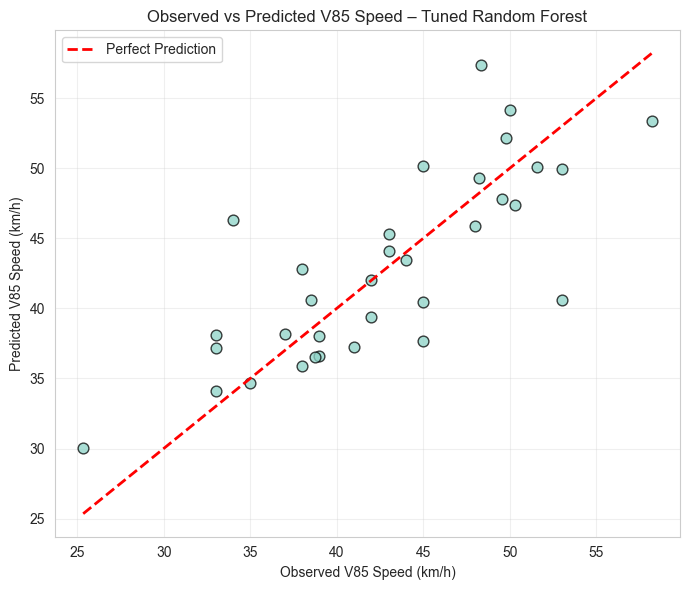

In [88]:
plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_test_pred_rf_tuned,
    s=60,
    alpha=0.75,
    edgecolor="black"
)

# Perfect prediction line
min_val = min(y_test.min(), y_test_pred_rf_tuned.min())
max_val = max(y_test.max(), y_test_pred_rf_tuned.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=2,
    color="red",
    label="Perfect Prediction"
)

plt.xlabel("Observed V85 Speed (km/h)")
plt.ylabel("Predicted V85 Speed (km/h)")
plt.title("Observed vs Predicted V85 Speed – Tuned Random Forest")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [89]:
rf_residuals = y_test - y_test_pred_rf_tuned

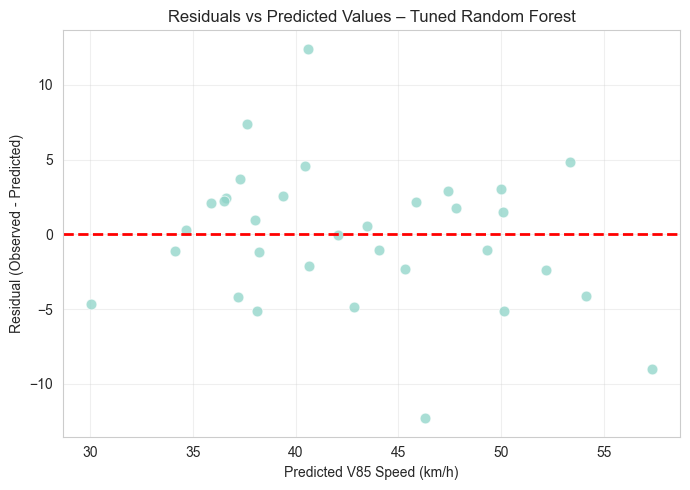

In [90]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    x=y_test_pred_rf_tuned,
    y=rf_residuals,
    s=60,
    alpha=0.75
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Predicted V85 Speed (km/h)")
plt.ylabel("Residual (Observed - Predicted)")
plt.title("Residuals vs Predicted Values – Tuned Random Forest")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

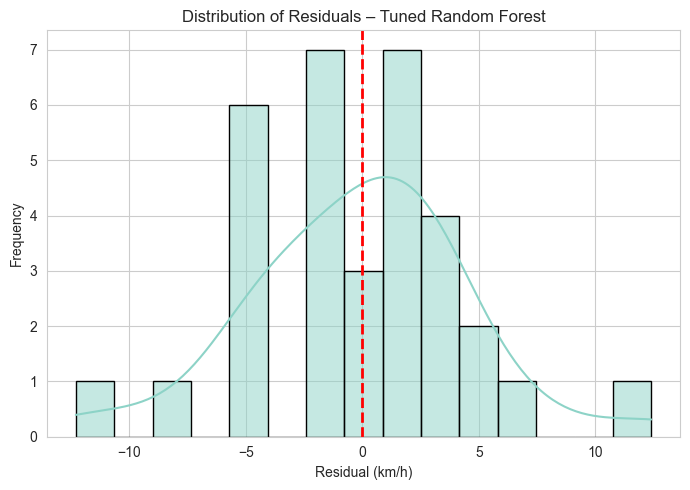

In [91]:
plt.figure(figsize=(7, 5))

sns.histplot(
    rf_residuals,
    bins=15,
    kde=True,
    edgecolor="black"
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Residual (km/h)")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals – Tuned Random Forest")

plt.tight_layout()
plt.show()

In [92]:
residual_summary = pd.DataFrame({
    "Statistic": [
        "Mean Residual",
        "Median Residual",
        "Residual SD",
        "Minimum Residual",
        "Maximum Residual"
    ],

    "Value": [
        np.mean(rf_residuals),
        np.median(rf_residuals),
        np.std(rf_residuals),
        np.min(rf_residuals),
        np.max(rf_residuals)
    ]
})

residual_summary.round(3)

,Statistic,Value
0,Mean Residual,-0.168
1,Median Residual,0.317
2,Residual SD,4.608
3,Minimum Residual,-12.299
4,Maximum Residual,12.402


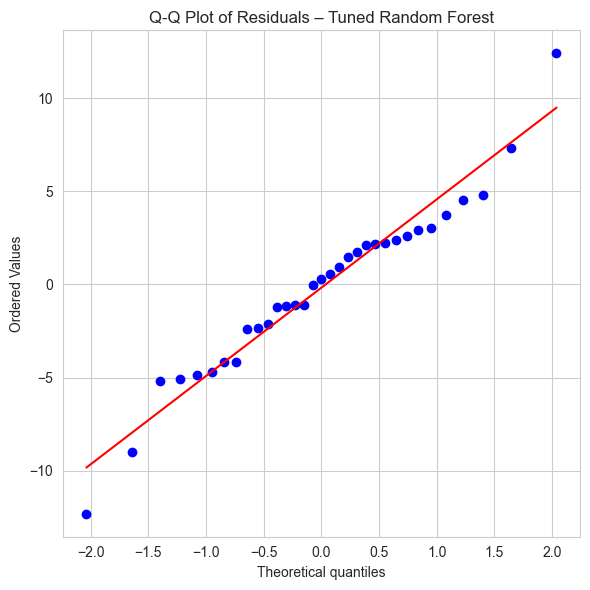

In [93]:
import scipy.stats as stats

plt.figure(figsize=(6, 6))

stats.probplot(
    rf_residuals,
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot of Residuals – Tuned Random Forest")

plt.tight_layout()
plt.show()

In [94]:
feature_importance_rf = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance_rf = feature_importance_rf.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_rf.round(3)

,Feature,Importance
0,Radius of Curve,0.620
1,Gradient,0.214
2,Average Shoulder Width,0.092
3,Carriageway Width,0.074


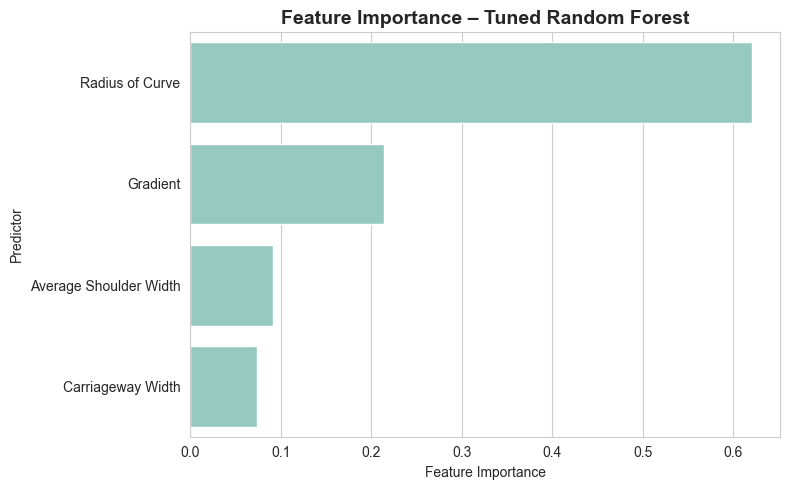

In [95]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=feature_importance_rf,
    x="Importance",
    y="Feature"
)

plt.title(
    "Feature Importance – Tuned Random Forest",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Feature Importance")
plt.ylabel("Predictor")

plt.tight_layout()
plt.show()

In [96]:
from sklearn.inspection import permutation_importance

perm_rf = permutation_importance(
    best_rf,
    X_test,
    y_test,
    n_repeats=100,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

permutation_importance_rf = pd.DataFrame({
    "Feature": X_test.columns,
    "Mean Importance": perm_rf.importances_mean,
    "SD Importance": perm_rf.importances_std
})

permutation_importance_rf = permutation_importance_rf.sort_values(
    by="Mean Importance",
    ascending=False
).reset_index(drop=True)

permutation_importance_rf.round(3)

,Feature,Mean Importance,SD Importance
0,Radius of Curve,1.155,0.284
1,Average Shoulder Width,0.044,0.028
2,Gradient,-0.015,0.064
3,Carriageway Width,-0.016,0.029


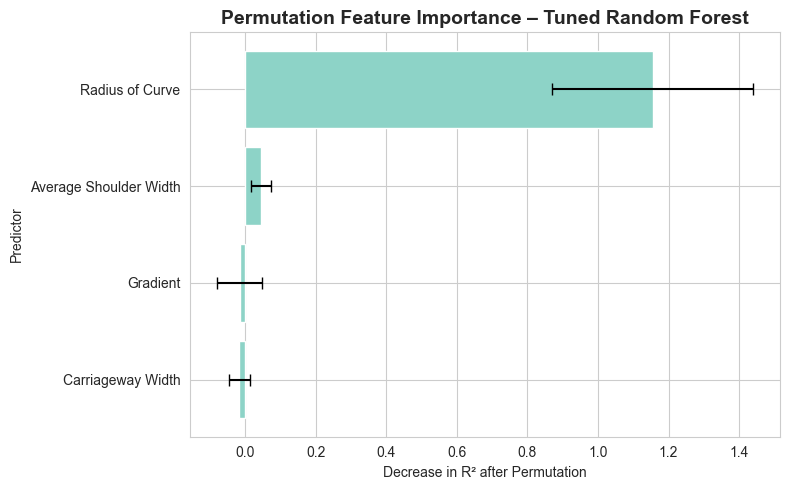

In [97]:
plt.figure(figsize=(8, 5))

plt.barh(
    permutation_importance_rf["Feature"],
    permutation_importance_rf["Mean Importance"],
    xerr=permutation_importance_rf["SD Importance"],
    capsize=4
)

plt.gca().invert_yaxis()

plt.xlabel("Decrease in R² after Permutation")
plt.ylabel("Predictor")

plt.title(
    "Permutation Feature Importance – Tuned Random Forest",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [98]:
from sklearn.inspection import PartialDependenceDisplay

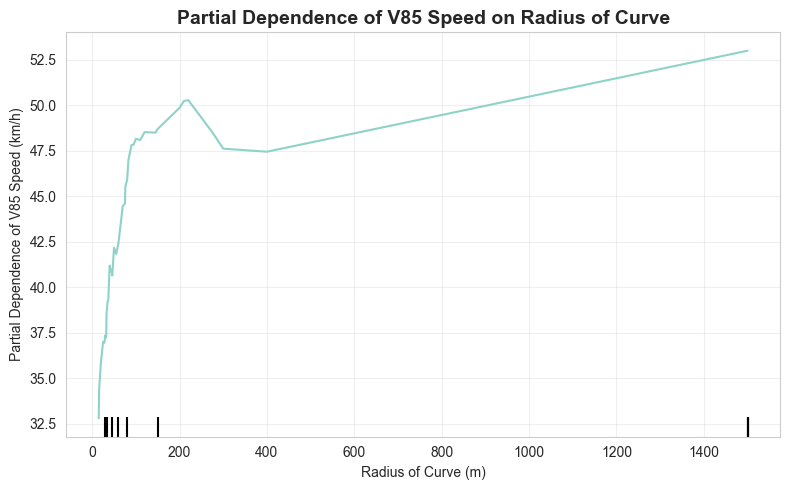

In [99]:
fig, ax = plt.subplots(figsize=(8, 5))

PartialDependenceDisplay.from_estimator(
    best_rf,
    X_train,
    features=["Radius of Curve"],
    kind="average",
    grid_resolution=100,
    ax=ax
)

plt.title(
    "Partial Dependence of V85 Speed on Radius of Curve",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Radius of Curve (m)")
plt.ylabel("Partial Dependence of V85 Speed (km/h)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

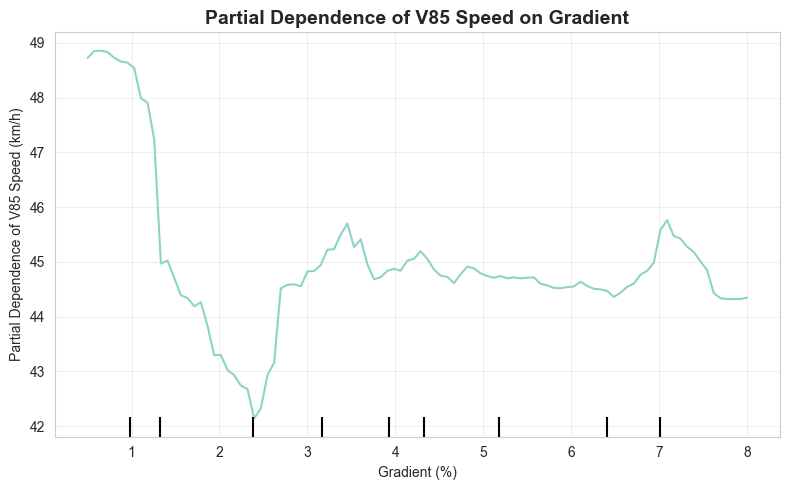

In [100]:
fig, ax = plt.subplots(figsize=(8, 5))

PartialDependenceDisplay.from_estimator(
    best_rf,
    X_train,
    features=["Gradient"],
    kind="average",
    grid_resolution=100,
    ax=ax
)

plt.title(
    "Partial Dependence of V85 Speed on Gradient",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Gradient (%)")
plt.ylabel("Partial Dependence of V85 Speed (km/h)")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

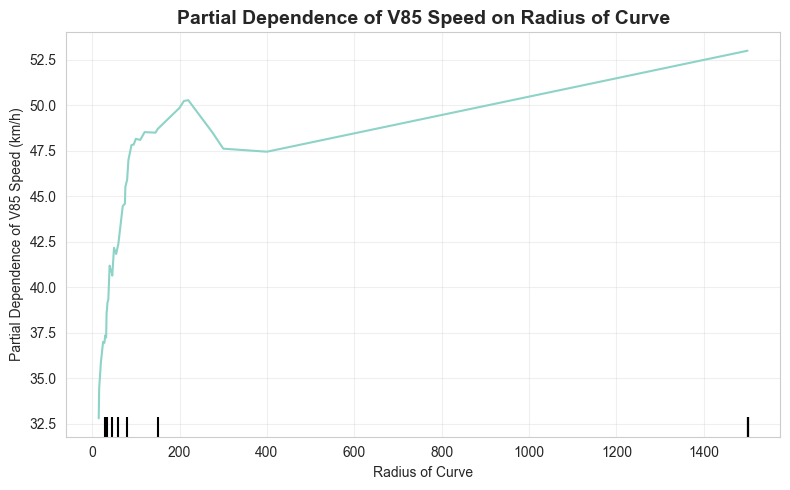

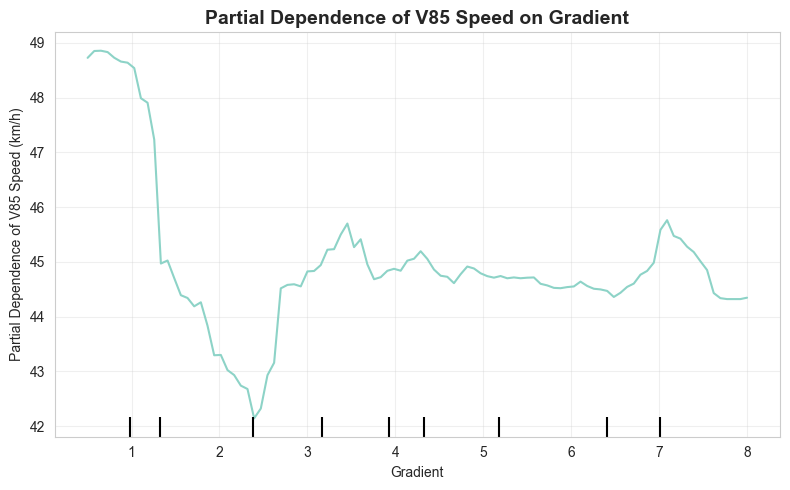

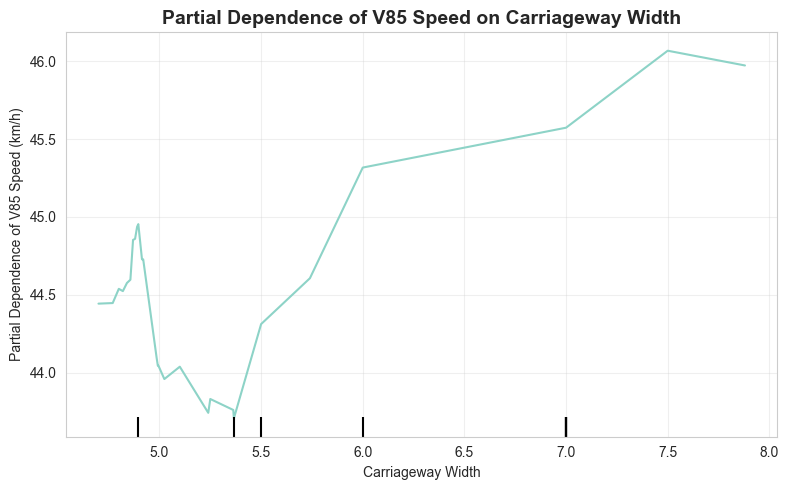

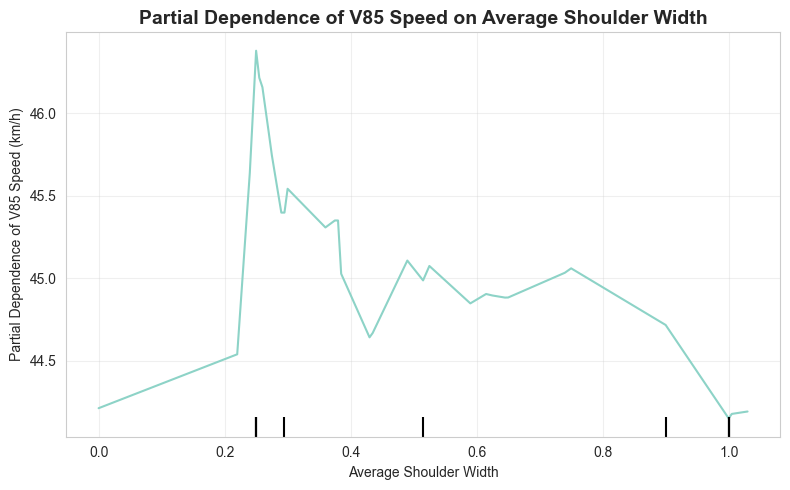

In [101]:
features_pdp = [
    "Radius of Curve",
    "Gradient",
    "Carriageway Width",
    "Average Shoulder Width"
]

for feature in features_pdp:

    fig, ax = plt.subplots(figsize=(8, 5))

    PartialDependenceDisplay.from_estimator(
        best_rf,
        X_train,
        features=[feature],
        kind="average",
        grid_resolution=100,
        ax=ax
    )

    plt.title(
        f"Partial Dependence of V85 Speed on {feature}",
        fontsize=14,
        fontweight="bold"
    )

    plt.xlabel(feature)
    plt.ylabel("Partial Dependence of V85 Speed (km/h)")

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

In [102]:
# Baseline data
df_R1500 = df_encoded.copy()

# Tangent = 1000 m
df_R1000 = df_encoded.copy()
df_R1000.loc[
    df_R1000["Radius of Curve"] == 1500,
    "Radius of Curve"
] = 1000

# Tangent = 2000 m
df_R2000 = df_encoded.copy()
df_R2000.loc[
    df_R2000["Radius of Curve"] == 1500,
    "Radius of Curve"
] = 2000

In [103]:
print("R1000 max radius:", df_R1000["Radius of Curve"].max())
print("R1500 max radius:", df_R1500["Radius of Curve"].max())
print("R2000 max radius:", df_R2000["Radius of Curve"].max())

R1000 max radius: 1000
R1500 max radius: 1500
R2000 max radius: 2000


In [104]:
# Identify tangent sections from the current R = 1500 coding
tangent_mask_train = X_train["Radius of Curve"] == 1500
tangent_mask_test = X_test["Radius of Curve"] == 1500

print("Tangents in training set:", tangent_mask_train.sum())
print("Tangents in testing set :", tangent_mask_test.sum())

Tangents in training set: 40
Tangents in testing set : 3


In [105]:
# -----------------------------
# Scenario 1: Tangent = 1000 m
# -----------------------------
X_train_R1000 = X_train.copy()
X_test_R1000 = X_test.copy()

X_train_R1000.loc[tangent_mask_train, "Radius of Curve"] = 1000
X_test_R1000.loc[tangent_mask_test, "Radius of Curve"] = 1000


# -----------------------------
# Scenario 2: Tangent = 1500 m
# Baseline/current dataset
# -----------------------------
X_train_R1500 = X_train.copy()
X_test_R1500 = X_test.copy()


# -----------------------------
# Scenario 3: Tangent = 2000 m
# -----------------------------
X_train_R2000 = X_train.copy()
X_test_R2000 = X_test.copy()

X_train_R2000.loc[tangent_mask_train, "Radius of Curve"] = 2000
X_test_R2000.loc[tangent_mask_test, "Radius of Curve"] = 2000

In [106]:
print(
    "R1000 tangent values:",
    X_train_R1000.loc[tangent_mask_train, "Radius of Curve"].unique()
)

print(
    "R1500 tangent values:",
    X_train_R1500.loc[tangent_mask_train, "Radius of Curve"].unique()
)

print(
    "R2000 tangent values:",
    X_train_R2000.loc[tangent_mask_train, "Radius of Curve"].unique()
)

R1000 tangent values: [1000]
R1500 tangent values: [1500]
R2000 tangent values: [2000]


In [107]:
from sklearn.base import clone

rf_R1000 = clone(best_rf)
rf_R1500 = clone(best_rf)
rf_R2000 = clone(best_rf)

rf_R1000.fit(X_train_R1000, y_train)
rf_R1500.fit(X_train_R1500, y_train)
rf_R2000.fit(X_train_R2000, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [108]:
pred_R1000 = rf_R1000.predict(X_test_R1000)
pred_R1500 = rf_R1500.predict(X_test_R1500)
pred_R2000 = rf_R2000.predict(X_test_R2000)

In [109]:
def evaluate_model(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred)
    }


result_R1000 = evaluate_model(y_test, pred_R1000)
result_R1500 = evaluate_model(y_test, pred_R1500)
result_R2000 = evaluate_model(y_test, pred_R2000)

In [110]:
radius_sensitivity = pd.DataFrame({
    "Tangent Radius (m)": [1000, 1500, 2000],

    "Test R2": [
        result_R1000["R2"],
        result_R1500["R2"],
        result_R2000["R2"]
    ],

    "Test RMSE": [
        result_R1000["RMSE"],
        result_R1500["RMSE"],
        result_R2000["RMSE"]
    ],

    "Test MAE": [
        result_R1000["MAE"],
        result_R1500["MAE"],
        result_R2000["MAE"]
    ]
})

radius_sensitivity.round(3)

,Tangent Radius (m),Test R2,Test RMSE,Test MAE
0,1000,0.589,4.611,3.517
1,1500,0.589,4.611,3.517
2,2000,0.589,4.611,3.517


In [111]:
# Create copies
X_train_tangent = X_train.copy()
X_test_tangent = X_test.copy()

# Create explicit tangent indicator
X_train_tangent["is_tangent"] = (
    X_train_tangent["Radius of Curve"] == 1500
).astype(int)

X_test_tangent["is_tangent"] = (
    X_test_tangent["Radius of Curve"] == 1500
).astype(int)

In [112]:
curve_radius_median = X_train_tangent.loc[
    X_train_tangent["is_tangent"] == 0,
    "Radius of Curve"
].median()

print("Median radius of actual curves:",
      curve_radius_median)

Median radius of actual curves: 50.0


In [113]:
X_train_tangent.loc[
    X_train_tangent["is_tangent"] == 1,
    "Radius of Curve"
] = curve_radius_median

X_test_tangent.loc[
    X_test_tangent["is_tangent"] == 1,
    "Radius of Curve"
] = curve_radius_median

In [114]:
from sklearn.base import clone

rf_with_tangent = clone(best_rf)

rf_with_tangent.fit(
    X_train_tangent,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsam

In [115]:
y_train_pred_tangent = rf_with_tangent.predict(
    X_train_tangent
)

y_test_pred_tangent = rf_with_tangent.predict(
    X_test_tangent
)

In [116]:
tangent_train_r2 = r2_score(
    y_train,
    y_train_pred_tangent
)

tangent_test_r2 = r2_score(
    y_test,
    y_test_pred_tangent
)

tangent_test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_test_pred_tangent
    )
)

tangent_test_mae = mean_absolute_error(
    y_test,
    y_test_pred_tangent
)

tangent_indicator_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],
    "Baseline R1500": [
        rf_tuned_test_r2,
        rf_tuned_test_rmse,
        rf_tuned_test_mae
    ],
    "Radius + is_tangent": [
        tangent_test_r2,
        tangent_test_rmse,
        tangent_test_mae
    ]
})

tangent_indicator_results.round(3)

,Metric,Baseline R1500,Radius + is_tangent
0,R2,0.589,0.634
1,RMSE,4.611,4.352
2,MAE,3.517,3.243


In [117]:
from sklearn.base import BaseEstimator, TransformerMixin

class TangentTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, tangent_value=1500):
        self.tangent_value = tangent_value

    def fit(self, X, y=None):
        X = X.copy()

        curve_mask = X["Radius of Curve"] != self.tangent_value

        self.curve_radius_median_ = X.loc[
            curve_mask,
            "Radius of Curve"
        ].median()

        return self

    def transform(self, X):
        X = X.copy()

        # Create tangent indicator
        X["is_tangent"] = (
            X["Radius of Curve"] == self.tangent_value
        ).astype(int)

        # Replace artificial tangent radius
        X.loc[
            X["is_tangent"] == 1,
            "Radius of Curve"
        ] = self.curve_radius_median_

        return X

In [118]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

rf_tangent_pipeline = Pipeline([
    ("tangent", TangentTransformer(tangent_value=1500)),

    ("model", RandomForestRegressor(
        random_state=42
    ))
])

In [119]:
param_grid_rf_tangent = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 5, 10, 15],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", "log2"]
}

In [120]:
from sklearn.model_selection import KFold, GridSearchCV, cross_validate

inner_cv_tangent = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

outer_cv_tangent = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "R2": "r2",
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error"
}

In [121]:
grid_rf_tangent_nested = GridSearchCV(
    estimator=rf_tangent_pipeline,
    param_grid=param_grid_rf_tangent,
    cv=inner_cv_tangent,
    scoring="r2",
    n_jobs=-1
)

nested_rf_tangent = cross_validate(
    grid_rf_tangent_nested,
    X_train,
    y_train,
    cv=outer_cv_tangent,
    scoring=scoring,
    n_jobs=1
)

In [122]:
rf_tangent_nested_results = pd.DataFrame({
    "Metric": ["R2", "RMSE", "MAE"],

    "Mean": [
        nested_rf_tangent["test_R2"].mean(),
        -nested_rf_tangent["test_RMSE"].mean(),
        -nested_rf_tangent["test_MAE"].mean()
    ],

    "SD": [
        nested_rf_tangent["test_R2"].std(),
        nested_rf_tangent["test_RMSE"].std(),
        nested_rf_tangent["test_MAE"].std()
    ]
})

rf_tangent_nested_results.round(3)

,Metric,Mean,SD
0,R2,0.477,0.089
1,RMSE,6.959,0.965
2,MAE,5.550,0.749


In [123]:
tangent_model_comparison = pd.DataFrame({
    "Model": [
        "RF - Radius 1500",
        "RF - Radius + is_tangent"
    ],

    "Mean Nested CV R2": [
        tuned_rf_cv["test_R2"].mean(),
        nested_rf_tangent["test_R2"].mean()
    ],

    "SD R2": [
        tuned_rf_cv["test_R2"].std(),
        nested_rf_tangent["test_R2"].std()
    ],

    "Mean Nested CV RMSE": [
        -tuned_rf_cv["test_RMSE"].mean(),
        -nested_rf_tangent["test_RMSE"].mean()
    ],

    "SD RMSE": [
        tuned_rf_cv["test_RMSE"].std(),
        nested_rf_tangent["test_RMSE"].std()
    ],

    "Mean Nested CV MAE": [
        -tuned_rf_cv["test_MAE"].mean(),
        -nested_rf_tangent["test_MAE"].mean()
    ],

    "SD MAE": [
        tuned_rf_cv["test_MAE"].std(),
        nested_rf_tangent["test_MAE"].std()
    ]
})

tangent_model_comparison.round(3)

,Model,Mean Nested CV R2,SD R2,Mean Nested CV RMSE,SD RMSE,Mean Nested CV MAE,SD MAE
0,RF - Radius 1500,0.507,0.083,6.805,1.209,5.428,0.963
1,RF - Radius + is_tangent,0.477,0.089,6.959,0.965,5.550,0.749


In [124]:
final_model_table = pd.DataFrame({
    "Model": [
        "MLR",
        "Tuned Random Forest",
        "Tuned XGBoost",
        "Tuned SVR",
        "Tuned ANN"
    ],

    "Test R2": [
        mlr_test_r2,
        rf_tuned_test_r2,
        xgb_tuned_test_r2,
        svr_tuned_test_r2,
        ann_tuned_test_r2
    ],

    "Test RMSE": [
        mlr_test_rmse,
        rf_tuned_test_rmse,
        xgb_tuned_test_rmse,
        svr_tuned_test_rmse,
        ann_tuned_test_rmse
    ],

    "Test MAE": [
        mlr_test_mae,
        rf_tuned_test_mae,
        xgb_tuned_test_mae,
        svr_tuned_test_mae,
        ann_tuned_test_mae
    ],

    "Mean CV R2": [
        cv_comparison.loc[
            cv_comparison["Model"] == "MLR",
            "Mean CV R2"
        ].values[0],

        cv_comparison.loc[
            cv_comparison["Model"] == "Tuned RF",
            "Mean CV R2"
        ].values[0],

        cv_comparison.loc[
            cv_comparison["Model"] == "Tuned XGBoost",
            "Mean CV R2"
        ].values[0],

        cv_comparison.loc[
            cv_comparison["Model"] == "Tuned SVR",
            "Mean CV R2"
        ].values[0],

        cv_comparison.loc[
            cv_comparison["Model"] == "Tuned ANN",
            "Mean CV R2"
        ].values[0]
    ],

    "Mean CV RMSE": [
        cv_comparison.loc[
            cv_comparison["Model"] == "MLR",
            "Mean CV RMSE"
        ].values[0],

        cv_comparison.loc[
            cv_comparison["Model"] == "Tuned RF",
            "Mean CV RMSE"
        ].values[0],

        cv_comparison.loc[
            cv_comparison["Model"] == "Tuned XGBoost",
            "Mean CV RMSE"
        ].values[0],

        cv_comparison.loc[
            cv_comparison["Model"] == "Tuned SVR",
            "Mean CV RMSE"
        ].values[0],

        cv_comparison.loc[
            cv_comparison["Model"] == "Tuned ANN",
            "Mean CV RMSE"
        ].values[0]
    ],

    "Mean CV MAE": [
        cv_comparison.loc[
            cv_comparison["Model"] == "MLR",
            "Mean CV MAE"
        ].values[0],

        cv_comparison.loc[
            cv_comparison["Model"] == "Tuned RF",
            "Mean CV MAE"
        ].values[0],

        cv_comparison.loc[
            cv_comparison["Model"] == "Tuned XGBoost",
            "Mean CV MAE"
        ].values[0],

        cv_comparison.loc[
            cv_comparison["Model"] == "Tuned SVR",
            "Mean CV MAE"
        ].values[0],

        cv_comparison.loc[
            cv_comparison["Model"] == "Tuned ANN",
            "Mean CV MAE"
        ].values[0]
    ]
})

final_model_table.round(3)

,Model,Test R2,Test RMSE,Test MAE,Mean CV R2,Mean CV RMSE,Mean CV MAE
0,MLR,0.283,6.088,4.803,0.359,7.706,6.231
1,Tuned Random Forest,0.589,4.611,3.517,0.520,6.691,5.325
2,Tuned XGBoost,0.610,4.492,3.413,0.504,6.825,5.467
3,Tuned SVR,0.266,6.164,4.687,0.347,7.811,6.335
4,Tuned ANN,0.409,5.528,4.494,0.428,7.343,6.020


In [125]:
print("Final Tuned Random Forest Parameters:")
print(best_rf.get_params())

Final Tuned Random Forest Parameters:
{'bootstrap': True, 'ccp_alpha': 0.0, 'criterion': 'squared_error', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [126]:
final_rf_parameters = pd.DataFrame({
    "Hyperparameter": [
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "max_features"
    ],
    "Selected Value": [
        best_rf.get_params()["n_estimators"],
        best_rf.get_params()["max_depth"],
        best_rf.get_params()["min_samples_split"],
        best_rf.get_params()["min_samples_leaf"],
        best_rf.get_params()["max_features"]
    ]
})

final_rf_parameters

,Hyperparameter,Selected Value
0,n_estimators,200
1,max_depth,None
2,min_samples_split,5
3,min_samples_leaf,1
4,max_features,sqrt


In [127]:
final_rf_performance = pd.DataFrame({
    "Evaluation": [
        "Hold-out Test",
        "5-Fold CV",
        "Nested CV",
        "Bootstrap Test"
    ],
    "R2": [
        rf_tuned_test_r2,
        cv_comparison.loc[
            cv_comparison["Model"] == "Tuned RF",
            "Mean CV R2"
        ].values[0],
        tuned_rf_cv["test_R2"].mean(),
        rf_r2_mean
    ],
    "RMSE": [
        rf_tuned_test_rmse,
        cv_comparison.loc[
            cv_comparison["Model"] == "Tuned RF",
            "Mean CV RMSE"
        ].values[0],
        -tuned_rf_cv["test_RMSE"].mean(),
        rf_rmse_mean
    ],
    "MAE": [
        rf_tuned_test_mae,
        cv_comparison.loc[
            cv_comparison["Model"] == "Tuned RF",
            "Mean CV MAE"
        ].values[0],
        -tuned_rf_cv["test_MAE"].mean(),
        rf_mae_mean
    ]
})

final_rf_performance.round(3)

,Evaluation,R2,RMSE,MAE
0,Hold-out Test,0.589,4.611,3.517
1,5-Fold CV,0.520,6.691,5.325
2,Nested CV,0.507,6.805,5.428
3,Bootstrap Test,0.560,4.550,3.514


In [128]:
final_features = [
    "Gradient",
    "Radius of Curve",
    "Carriageway Width",
    "Average Shoulder Width"
]

print("Final Predictors:")
for feature in final_features:
    print("-", feature)

Final Predictors:
- Gradient
- Radius of Curve
- Carriageway Width
- Average Shoulder Width
